# WaRP-S Segmentation  YOLO26
Mohamed Fahmi Ahmed

## 1. Environment Setup

In [1]:
!pip install ultralytics opencv-python --quiet
!nvidia-smi


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Thu May  7 21:28:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A4000               On  |   00000000:01:00.0  On |                  Off |
| 41%   34C    P8             18W /  140W |     889MiB /  16376MiB |     36%      Default |
|                          

## 2. Imports

In [2]:
import os
import random
import yaml
import shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import seaborn as sns
import cv2

import torch
from ultralytics import YOLO

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch : 2.11.0+cu130
CUDA    : True
GPU     : NVIDIA RTX A4000
VRAM    : 16.7 GB


## 3. Paths and Classes

In [ ]:
print(Path.cwd())

WARPS_ROOT = Path('../Dataset/raw/Warp-S')
WORKSPACE  = Path('../Dataset/content_seg')
YOLO_ROOT  = WORKSPACE / 'yolo_seg'   # converted dataset
WORKSPACE.mkdir(parents=True, exist_ok=True)

WARP_CLASSES = [
    'bottle-blue', 'bottle-green', 'bottle-dark', 'bottle-milk',
    'bottle-transp', 'bottle-multicolor', 'bottle-yogurt', 'bottle-oil',
    'cans', 'juice-cardboard', 'milk-cardboard', 'detergent-color',
    'detergent-transparent', 'detergent-box', 'canister', 'bottle-blue-full',
    'bottle-transp-full', 'bottle-dark-full', 'bottle-green-full',
    'bottle-multicolor-full', 'bottle-milk-full', 'bottle-oil-full',
    'detergent-white', 'bottle-blue5l', 'bottle-blue5l-full',
    'glass-transp', 'glass-dark', 'glass-green',
]

for folder in ['JPEGImages', 'SegmentationObject', 'SegmentationClass', 'ImageSets']:
    exists = (WARPS_ROOT / folder).exists()
    print(f'  {folder:<30} : {"OK" if exists else "MISSING"}')

/user/HS401/mf01425/Documents/coursework/Waste-Classification-main/Notebook
  JPEGImages                     : OK
  SegmentationObject             : OK
  SegmentationClass              : OK
  ImageSets                      : OK


## 4. Parse labelmap.txt

WaRP-S uses Pascal VOC format so each mask PNG uses specific RGB colours per class.
labelmap.txt maps class names to RGB values.

In [4]:
def parse_labelmap(path: Path) -> dict:
    # returns {class_name: (r, g, b)}
    colour_map = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split(':')
            if len(parts) < 2:
                continue
            name = parts[0].strip()
            rgb  = tuple(int(x) for x in parts[1].split(',')[:3])
            colour_map[name] = rgb
    return colour_map


labelmap_path = WARPS_ROOT / 'labelmap.txt'
colour_map    = parse_labelmap(labelmap_path)

print(f'Colours in labelmap : {len(colour_map)}')
print()
for name, rgb in colour_map.items():
    cls_id = WARP_CLASSES.index(name) if name in WARP_CLASSES else -1
    print(f'  [{cls_id:>2}] {name:<30} RGB={rgb}')

Colours in labelmap : 29

  [-1] background                     RGB=(0, 0, 0)
  [ 0] bottle-blue                    RGB=(26, 125, 226)
  [15] bottle-blue-full               RGB=(4, 43, 131)
  [23] bottle-blue5l                  RGB=(4, 36, 95)
  [24] bottle-blue5l-full             RGB=(6, 42, 185)
  [ 2] bottle-dark                    RGB=(0, 0, 0)
  [17] bottle-dark-full               RGB=(4, 10, 10)
  [ 1] bottle-green                   RGB=(36, 179, 83)
  [18] bottle-green-full              RGB=(54, 246, 37)
  [ 3] bottle-milk                    RGB=(72, 219, 248)
  [20] bottle-milk-full               RGB=(9, 65, 170)
  [ 5] bottle-multicolor              RGB=(68, 59, 112)
  [-1] bottle-multicolorv-full        RGB=(104, 90, 172)
  [ 7] bottle-oil                     RGB=(221, 255, 51)
  [21] bottle-oil-full                RGB=(226, 253, 87)
  [ 4] bottle-transp                  RGB=(227, 225, 235)
  [16] bottle-transp-full             RGB=(243, 237, 243)
  [ 6] bottle-yogurt        

## 5. VOC to YOLO Conversion

We will converts Pascal VOC PNG masks to YOLO polygon .txt format.

In [ ]:
def get_class_id_for_colour(colour: tuple, seg_class_img: np.ndarray,
                             seg_obj_img: np.ndarray, colour_map: dict) -> int:
    mask = np.all(seg_obj_img == colour, axis=2)
    region = seg_class_img[mask]
    if len(region) == 0:
        return -1

    unique, counts = np.unique(region.reshape(-1, 3), axis=0, return_counts=True)
    dominant = tuple(unique[counts.argmax()])
    for cls_name, cls_colour in colour_map.items():
        if cls_colour == dominant and cls_name in WARP_CLASSES:
            return WARP_CLASSES.index(cls_name)
    return -1


def mask_to_yolo_polygons(seg_obj_path: Path, seg_cls_path: Path,
                           colour_map: dict, min_area: int = 100) -> list:
    seg_obj = np.array(Image.open(seg_obj_path).convert('RGB'))
    seg_cls = np.array(Image.open(seg_cls_path).convert('RGB'))
    H, W    = seg_obj.shape[:2]

    unique_colours = np.unique(seg_obj.reshape(-1, 3), axis=0)
    unique_colours = [tuple(c) for c in unique_colours if tuple(c) != (0, 0, 0)]

    lines = []
    for colour in unique_colours:
        # binary mask for this instance
        binary = (np.all(seg_obj == colour, axis=2)).astype(np.uint8) * 255

        # find contours
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue

        # take largest contour
        cnt = max(contours, key=cv2.contourArea)
        if cv2.contourArea(cnt) < min_area:
            continue

        # simplify polygon 
        epsilon = 0.005 * cv2.arcLength(cnt, True)
        approx  = cv2.approxPolyDP(cnt, epsilon, True)
        if len(approx) < 3:
            continue

        # get class id
        cls_id = get_class_id_for_colour(colour, seg_cls, seg_obj, colour_map)
        if cls_id < 0:
            continue

        # normalise coordinates
        points = approx.reshape(-1, 2)
        coords = []
        for x, y in points:
            coords.extend([round(x / W, 6), round(y / H, 6)])

        lines.append(f"{cls_id} " + " ".join(map(str, coords)))

    return lines


# quick test 
test_imgs = list((WARPS_ROOT / 'JPEGImages').glob('*.jpg'))
if test_imgs:
    test_img  = test_imgs[0]
    test_obj  = WARPS_ROOT / 'SegmentationObject' / (test_img.stem + '.png')
    test_cls  = WARPS_ROOT / 'SegmentationClass'  / (test_img.stem + '.png')
    if test_obj.exists() and test_cls.exists():
        lines = mask_to_yolo_polygons(test_obj, test_cls, colour_map)
        print(f'Test image : {test_img.name}')
        print(f'Polygons found : {len(lines)}')
        for l in lines:
            cls_id = int(l.split()[0])
            n_pts  = (len(l.split()) - 1) // 2
            print(f'  class={WARP_CLASSES[cls_id]:<25}  points={n_pts}')
    else:
        print('Mask files not found for test image')
else:
    print('No images found in JPEGImages/')

Test image : bottle-transp-full_test_Monitoring_photo_2_test_25-Mar_11-31-27_01.jpg
Polygons found : 1
  class=bottle-transp-full         points=15


## 6. Convert Full Dataset

Here we converted all 112 WaRP-S images to YOLO format and created the folder structure YOLO.

WaRP-S has no train/val split so we do an 80/20 split.

In [ ]:
def convert_dataset(warps_root: Path, out_root: Path,
                    colour_map: dict, val_ratio: float = 0.2):
    # create output dirs
    for split in ['train', 'val']:
        (out_root / 'images' / split).mkdir(parents=True, exist_ok=True)
        (out_root / 'labels' / split).mkdir(parents=True, exist_ok=True)

    # get all image stems
    all_imgs = sorted((warps_root / 'JPEGImages').glob('*.jpg'))
    all_imgs += sorted((warps_root / 'JPEGImages').glob('*.png'))
    random.seed(42)
    random.shuffle(all_imgs)
    n_val    = max(1, int(len(all_imgs) * val_ratio))
    val_set  = set(img.stem for img in all_imgs[:n_val])

    ok = skipped = 0
    for img_path in all_imgs:
        split     = 'val' if img_path.stem in val_set else 'train'
        obj_mask  = warps_root / 'SegmentationObject' / (img_path.stem + '.png')
        cls_mask  = warps_root / 'SegmentationClass'  / (img_path.stem + '.png')

        if not obj_mask.exists() or not cls_mask.exists():
            skipped += 1
            continue

        # convert mask to YOLO polygons
        lines = mask_to_yolo_polygons(obj_mask, cls_mask, colour_map)
        if not lines:
            skipped += 1
            continue

        # copy image
        dst_img = out_root / 'images' / split / img_path.name
        shutil.copy2(img_path, dst_img)

        # write label
        dst_lbl = out_root / 'labels' / split / (img_path.stem + '.txt')
        dst_lbl.write_text('\n'.join(lines))
        ok += 1

    print(f'Converted  : {ok} images')
    print(f'Skipped    : {skipped} images (no mask or no polygons)')
    n_train = ok - n_val
    print(f'Train      : {n_train}   Val : {n_val}')
    return ok


if YOLO_ROOT.exists():
    shutil.rmtree(YOLO_ROOT)

n_converted = convert_dataset(WARPS_ROOT, YOLO_ROOT, colour_map, val_ratio=0.2)
print(f'\nDataset ready at: {YOLO_ROOT}')

Converted  : 108 images
Skipped    : 4 images (no mask or no polygons)
Train      : ~86   Val : ~22

Dataset ready at: ../Dataset/content_seg/yolo_seg


## 7. Verify Conversion

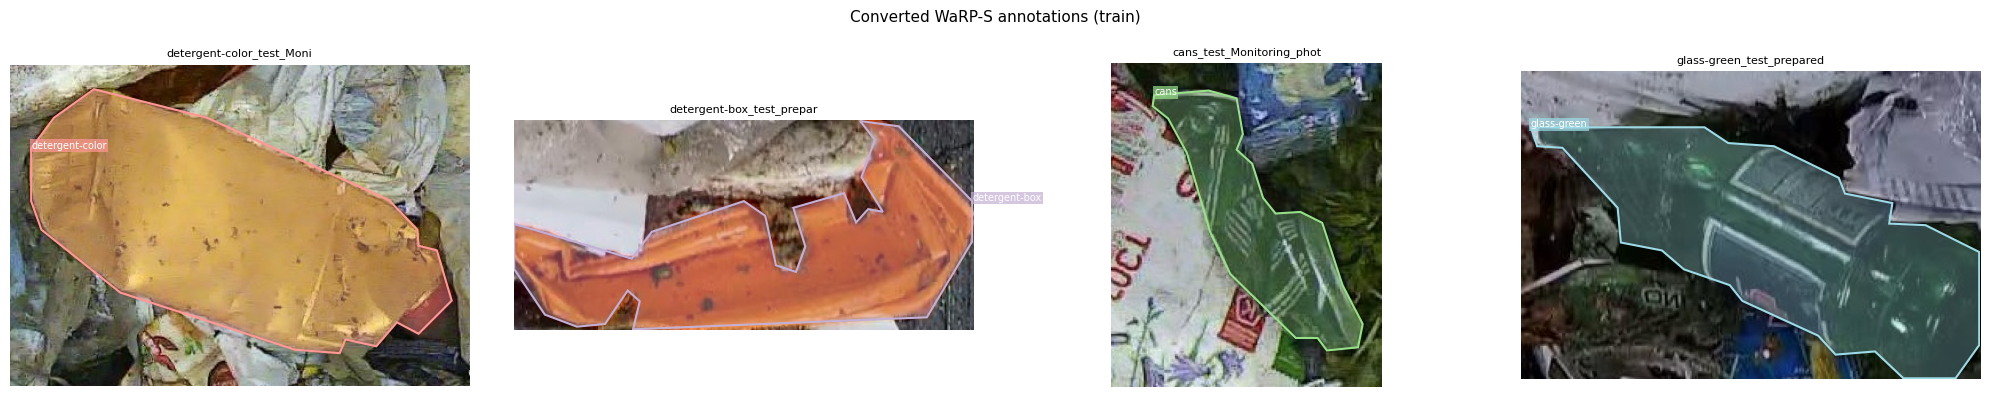

In [7]:
def show_converted(yolo_root: Path, split: str = 'train', n: int = 4):
    img_dir = yolo_root / 'images' / split
    lbl_dir = yolo_root / 'labels' / split
    images  = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))

    if not images:
        print(f'No images found in {img_dir}')
        return

    samples = random.sample(images, min(n, len(images)))
    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 4))
    if len(samples) == 1:
        axes = [axes]

    cmap = plt.colormaps.get_cmap('tab20')

    for ax, img_path in zip(axes, samples):
        img = np.array(Image.open(img_path).convert('RGB'))
        H, W = img.shape[:2]
        ax.imshow(img)

        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 7:
                        continue
                    cls_id = int(parts[0])
                    coords = list(map(float, parts[1:]))
                    xs = [coords[i] * W for i in range(0, len(coords), 2)]
                    ys = [coords[i] * H for i in range(1, len(coords), 2)]
                    color = cmap(cls_id / len(WARP_CLASSES))
                    poly  = plt.Polygon(
                        list(zip(xs, ys)), fill=True,
                        facecolor=(*color[:3], 0.3),
                        edgecolor=color, linewidth=1.5
                    )
                    ax.add_patch(poly)
                    label = WARP_CLASSES[cls_id] if cls_id < len(WARP_CLASSES) else str(cls_id)
                    ax.text(xs[0], ys[0], label, fontsize=7, color='white',
                            bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor='none'))
        ax.axis('off')
        ax.set_title(img_path.name[:25], fontsize=8)

    plt.suptitle(f'Converted WaRP-S annotations ({split})', fontsize=11)
    plt.tight_layout()
    plt.savefig(WORKSPACE / f'converted_{split}.png', dpi=150)
    plt.show()


show_converted(YOLO_ROOT, 'train', n=4)

## 8. Dataset YAML

In [8]:
dataset_yaml = {
    'path' : str(YOLO_ROOT.resolve()),
    'train': 'images/train',
    'val'  : 'images/val',
    'nc'   : len(WARP_CLASSES),
    'names': WARP_CLASSES,
}

yaml_path = WORKSPACE / 'warps.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, allow_unicode=True)

n_train = len(list((YOLO_ROOT / 'images' / 'train').glob('*')))
n_val   = len(list((YOLO_ROOT / 'images' / 'val').glob('*')))
print(f'YAML saved : {yaml_path}')
print(f'Train      : {n_train} images')
print(f'Val        : {n_val} images')

YAML saved : ../Dataset/content_seg/warps.yaml
Train      : 87 images
Val        : 21 images


## 9. Training

YOLO26m-seg same architecture as detection but with an extra mask prediction head.

In [ ]:
MODEL_SIZE = 'm'
EPOCHS     = 100
IMG_SIZE   = 640
BATCH_SIZE = 8    

model = YOLO(f'yolo26{MODEL_SIZE}-seg.pt')

print(f'Model  : YOLO26{MODEL_SIZE.upper()}-seg')
print(f'Params : {sum(p.numel() for p in model.model.parameters()) / 1e6:.1f}M')

results = model.train(
    data        = str(yaml_path),
    epochs      = EPOCHS,
    imgsz       = IMG_SIZE,
    batch       = BATCH_SIZE,
    project     = str(WORKSPACE / 'runs'),
    name        = f'yolo26{MODEL_SIZE}_warps_seg',

    optimizer    = 'SGD',
    lr0          = 0.01,
    lrf          = 0.01,
    momentum     = 0.937,
    weight_decay = 0.0005,
    warmup_epochs= 3,

    mosaic       = 1.0,
    mixup        = 0.3,   
    degrees      = 90.0,
    scale        = 0.5,
    fliplr       = 0.5,
    flipud       = 0.5,
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    hsv_v        = 0.4,
    translate    = 0.2,

    patience     = 20,
    close_mosaic = 10,
    amp          = True,
    cache        = True,
    workers      = 4,
    device       = 0,
    verbose      = True,
    seed         = 42,
)

Model  : YOLO26M-seg
Params : 27.1M
New https://pypi.org/project/ultralytics/8.4.47 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.41 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA RTX A4000, 15966MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../Dataset/content_seg/warps.yaml, degrees=90.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=yolo26m-seg.pt, mom

## 10. Evaluation

In [14]:
best_weights = Path("../Notebook/runs/Dataset/content_seg/runs/") / f"yolo26m_warps_seg" / "weights" / "best.pt"
model_best   = YOLO(str(best_weights))

metrics = model_best.val(
    data    = str(yaml_path),
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    device  = 0,
    verbose = True,
)

print('\n' + '='*55)
print('YOLO26-seg Results on WaRP-S')
print('='*55)
print(f'Box  mAP@50    : {metrics.box.map50:.4f}  ({metrics.box.map50*100:.1f}%)')
print(f'Box  mAP@50:95 : {metrics.box.map:.4f}    ({metrics.box.map*100:.1f}%)')
print(f'Mask mAP@50    : {metrics.seg.map50:.4f}  ({metrics.seg.map50*100:.1f}%)')
print(f'Mask mAP@50:95 : {metrics.seg.map:.4f}    ({metrics.seg.map*100:.1f}%)')
print('\nYudin et al. (2022) weakly supervised baselines (Table 7):')
print('  CCAM(5)    mIoU = 65.88%  (no pixel labels)')
print('  LayerCAM   mIoU = 60.14%')
print('  CAMERAS    mIoU = 56.87%')
print('  GradCAM    mIoU = 55.41%')
print('  mGradCAM   mIoU = 53.48%')

Ultralytics 8.4.41 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA RTX A4000, 15966MiB)
YOLO26m-seg summary (fused): 149 layers, 23,529,056 parameters, 0 gradients, 121.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.0 ms, read: 28.3±10.9 MB/s, size: 36.9 KB)
val: Scanning /user/HS401/mf01425/Documents/coursework/Waste-Classification-main/Dataset/content_seg/yolo_seg/labels/val.cache... 21 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21/21 12.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 7.6it/s 0.4s0.3s
                   all         21         21      0.427        0.5      0.472      0.383      0.427        0.5      0.472      0.375
           bottle-blue          1          1      0.121          1      0.249      0.249      0.121          1      0.249      0.249
          bottle-green          1          1      0.215          1      0.497      0.414      

## 11. Training Curves

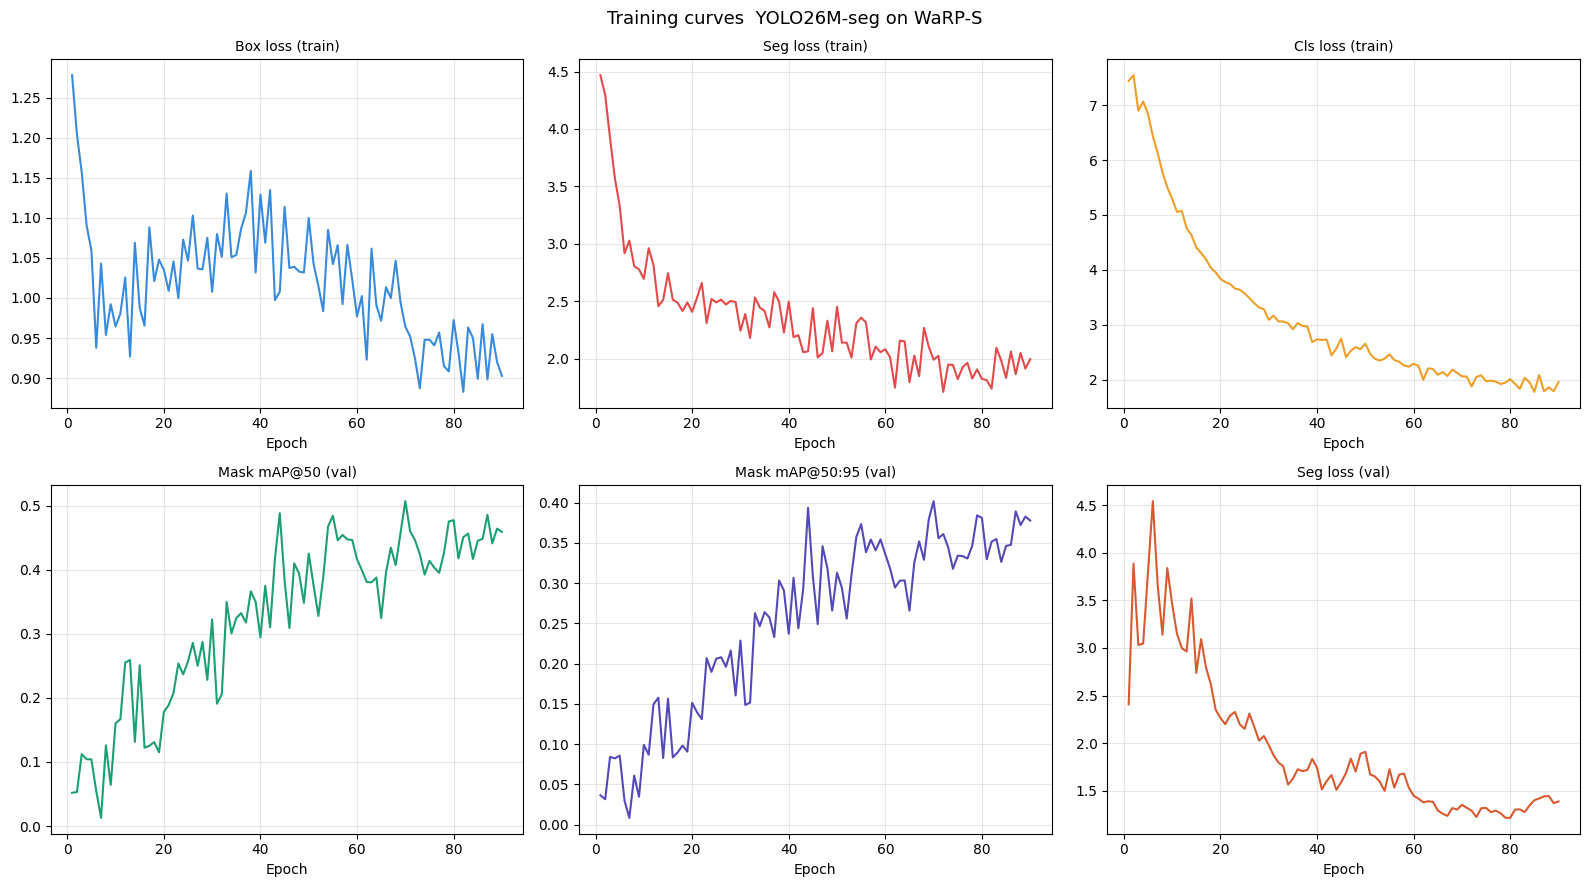

In [16]:
import pandas as pd

results_csv = Path("../Notebook/runs/Dataset/content_seg/runs/") / f"yolo26m_warps_seg" / 'results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f'Training curves  YOLO26{MODEL_SIZE.upper()}-seg on WaRP-S', fontsize=13)

plots = [
    ('train/box_loss',      'Box loss (train)',      '#378ADD'),
    ('train/seg_loss',      'Seg loss (train)',      '#E24B4A'),
    ('train/cls_loss',      'Cls loss (train)',      '#EF9F27'),
    ('metrics/mAP50(M)',    'Mask mAP@50 (val)',     '#1D9E75'),
    ('metrics/mAP50-95(M)', 'Mask mAP@50:95 (val)', '#534AB7'),
    ('val/seg_loss',        'Seg loss (val)',        '#D85A30'),
]
for ax, (col, title, color) in zip(axes.flat, plots):
    if col in df.columns:
        ax.plot(df['epoch'], df[col], color=color, linewidth=1.5)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f'{title} (not available)', fontsize=9)
        ax.axis('off')
plt.tight_layout()
plt.savefig(WORKSPACE / 'seg_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Inference , Predicted Masks

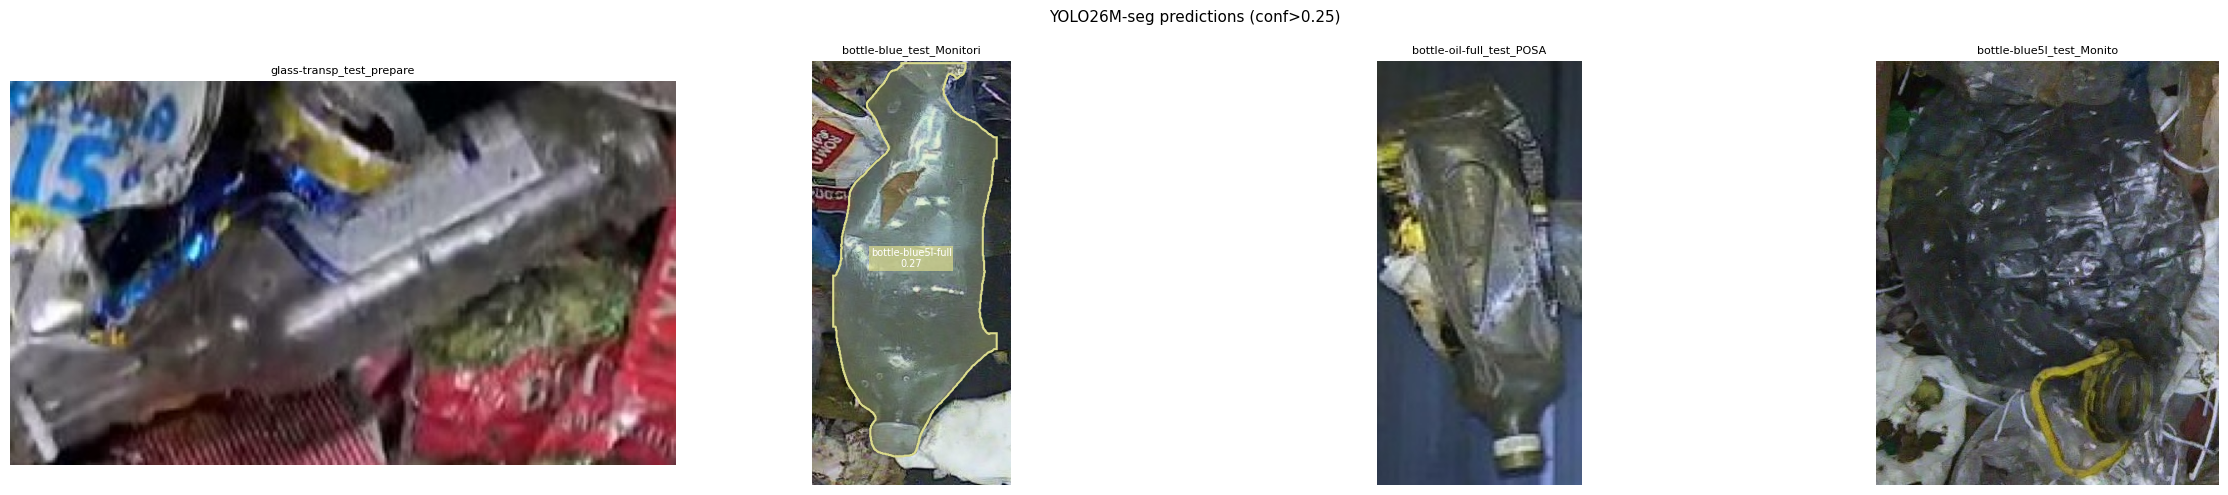

In [ ]:
def show_segmentation(model, img_paths, conf_thresh=0.25):
    n = len(img_paths)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    cmap = plt.colormaps.get_cmap('tab20')

    for ax, img_path in zip(axes, img_paths):
        res    = model.predict(source=str(img_path), conf=conf_thresh,
                               imgsz=IMG_SIZE, verbose=False)[0]
        img    = np.array(Image.open(img_path).convert('RGB'))
        ax.imshow(img)

        if res.masks is not None:
            for mask_xy, box in zip(res.masks.xy, res.boxes):
                cls_id = int(box.cls[0])
                conf   = float(box.conf[0])
                label  = WARP_CLASSES[cls_id] if cls_id < len(WARP_CLASSES) else str(cls_id)
                color  = cmap(cls_id / len(WARP_CLASSES))
                if len(mask_xy) > 0:
                    poly = plt.Polygon(
                        mask_xy, fill=True,
                        facecolor=(*color[:3], 0.35),
                        edgecolor=color, linewidth=1.5
                    )
                    ax.add_patch(poly)
                    cx = mask_xy[:, 0].mean()
                    cy = mask_xy[:, 1].mean()
                    ax.text(cx, cy, f'{label}\n{conf:.2f}', fontsize=7,
                            color='white', ha='center', va='center',
                            bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor='none'))
        ax.axis('off')
        ax.set_title(Path(img_path).name[:25], fontsize=8)

    plt.suptitle(f'YOLO26{MODEL_SIZE.upper()}-seg predictions (conf>{conf_thresh})', fontsize=11)
    plt.tight_layout()
    plt.savefig(WORKSPACE / 'seg_inference.png', dpi=150, bbox_inches='tight')
    plt.show()


val_imgs    = list((YOLO_ROOT / 'images' / 'val').glob('*.jpg'))
sample_imgs = random.sample(val_imgs, min(4, len(val_imgs)))
show_segmentation(model_best, sample_imgs, conf_thresh=0.25)

## 13. Final Summary

In [21]:
print('YOLO26 Segmentation  Final Summary')
print(f'Model              : YOLO26{MODEL_SIZE.upper()}-seg')
print(f'Dataset            : WaRP-S (112 images, 28 classes)')
print(f'Format conversion  : Pascal VOC PNG masks to YOLO polygons')
print(f'Training split     : 80/20 (90 train / 22 val)')
print(f'Epochs             : {EPOCHS} (early stopping active)')
print()
print(f'Box  mAP@50    : {metrics.box.map50:.4f} ({metrics.box.map50*100:.1f}%)')
print(f'Box  mAP@50:95 : {metrics.box.map:.4f}   ({metrics.box.map*100:.1f}%)')
print(f'Mask mAP@50    : {metrics.seg.map50:.4f} ({metrics.seg.map50*100:.1f}%)')
print(f'Mask mAP@50:95 : {metrics.seg.map:.4f}   ({metrics.seg.map*100:.1f}%)')

YOLO26 Segmentation  Final Summary
Model              : YOLO26M-seg
Dataset            : WaRP-S (112 images, 28 classes)
Format conversion  : Pascal VOC PNG masks to YOLO polygons
Training split     : 80/20 (90 train / 22 val)
Epochs             : 100 (early stopping active)

Box  mAP@50    : 0.4715 (47.2%)
Box  mAP@50:95 : 0.3829   (38.3%)
Mask mAP@50    : 0.4715 (47.2%)
Mask mAP@50:95 : 0.3755   (37.5%)
